# Is_Perfect, Random, histograma con densidad y anotaciones, mask

In [1]:
# IMPORTS
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

1.- Escribir una función que identifique si un número entero dado es un número perfecto (la suma de sus divisores propios es igual al número mismo). Usando plain Python, sin librerías

In [2]:
def is_perfect(n):
    suma=0
    for divisor in range(1, n):
        if n%divisor==0:
            suma+=divisor
    if suma==n:
        return True
    return False
    

# 6, 28, 496...
# Test Use Case
source_array = [233, 6, 5661, 348, 28, 901, 496, 1200, 8128, 2334]
expected_output = [False, True, False, False, True, False, True, False, True, False]
output = [is_perfect(n) for n in source_array] # This calls your function is_perfect
display(expected_output)
display(output)
assert(expected_output == output) # This will fail if the list is wrong

[False, True, False, False, True, False, True, False, True, False]

[False, True, False, False, True, False, True, False, True, False]

02 - 1.5pt

•Crear un array de NumPy de 1 dimensión con 50 elementos, y enteros aleatorios entre 1 y 100

•Crear un histograma para ese conjunto de datos agrupando por rangos de números de 10 en 10

•Mostrar la linea de densidad

•Mostrar la media y la mediana como líneas verticales en el gráfico


[96 47 18 97 66 32 56  1 67 56  7 70 34 76 91 80 74 11 93 96 61  0 14 54
 89 61 79 50 35 76 48 37 73 33 68 58 73 53 46 51 48 85 97 40 20 73 72 11
 84 39]
55.92
57.0


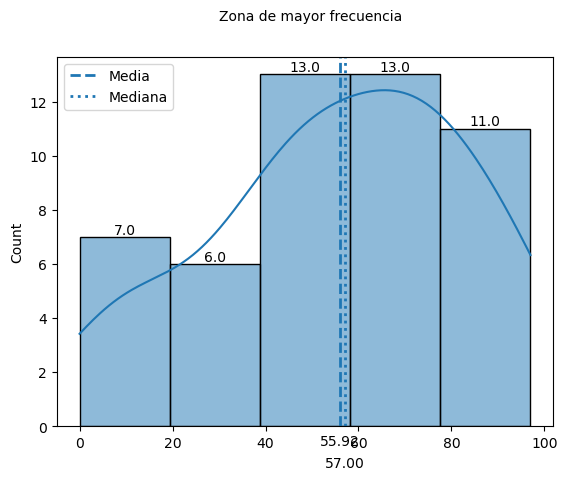

In [9]:
a=np.random.randint(101, size=50)
print(a)
media=a.mean()
mediana=np.median(a)
print(media)
print(mediana)

ax=sns.histplot(data=a, bins=int(len(a)/10), kde=True)


plt.axvline(media, linestyle="--", linewidth=2, label="Media")
plt.axvline(mediana, linestyle=":", linewidth=2, label="Mediana")
plt.text(x=30, y=15, s="Zona de mayor frecuencia", fontsize=10)
for p in ax.patches:
    plt.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
    
ax.text(media, -0.02, f"{media:.2f}", ha="center", va="top",transform=ax.get_xaxis_transform())

ax.text(mediana, -0.08, f"{mediana:.2f}", ha="center", va="top", transform=ax.get_xaxis_transform())
plt.legend()


plt.show()

03 - 1.5pt

•Crear una matriz cuadrada 6x6 con valores aleatorios enteros en el rango [-10,10]

•Restar a cada elemento de dicha matriz la media de su correspondiente columna (dicha media redondeada hacia el entero superior más cercano)

•Sustituir los valores negativos múltiplos de 3 por Nan

•Eliminar aquellas columnas que tengan 2 o más celdas con valores Nan

In [10]:
# Crear una matriz cuadrada 6x6 con valores aleatorios enteros en el rango [-10,10
a=np.random.randint(low=-10, high=11, size=(6, 6))


print(a)
# Restar a cada elemento de dicha matriz la media de su correspondiente columna (dicha media redondeada hacia el entero superior más cercano
z=np.shape(a)[1]
for ind_col in range(0, z):
    media=np.mean(a[:, ind_col])
    media=np.ceil(media)
    a[:, ind_col]=a[:, ind_col]-media



[[ -4  -3  -3  -1  -6   8]
 [  4   8   2   9  -2  -6]
 [  4   4  -7  -1   8  -4]
 [ -5  -2  -7  10  -7  -3]
 [-10  10   9  -6   1   3]
 [  0  -9  -2  -4  -9   6]]


In [12]:
# Sustituir los valores negativos múltiplos de 3 por Nan
frame = pd.DataFrame(a)
display(frame)


frame_nan = frame.mask((frame % 3 == 0) & (frame < 0))
display(frame_nan)

,0,1,2,3,4,5
0,-3,-5,-2,-3,-4,7
1,5,6,3,7,0,-7
2,5,2,-6,-3,10,-5
3,-4,-4,-6,8,-5,-4
4,-9,8,10,-8,3,2
5,1,-11,-1,-6,-7,5


,0,1,2,3,4,5
0,NaN,-5,-2.0,NaN,-4,7
1,5.0,6,3.0,7.0,0,-7
2,5.0,2,NaN,NaN,10,-5
3,-4.0,-4,NaN,8.0,-5,-4
4,NaN,8,10.0,-8.0,3,2
5,1.0,-11,-1.0,NaN,-7,5


In [55]:
# Eliminar aquellas columnas que tengan 2 o más celdas con valores Nan
frame_nan=frame_nan.dropna(thresh=z-1, axis=1)
display(frame_nan)

,0,1,2,5
0,NaN,0.0,5,7.0
1,7.0,NaN,9,NaN
2,-5.0,-10.0,-8,-4.0
3,-7.0,-8.0,4,-5.0
4,11.0,10.0,-7,0.0
5,-2.0,10.0,-5,9.0


04 - 1.5pt

•Escribir un generador que genere todos los factores de un número. Un factor es un número natural que puede dividir exactamente a otro número.

In [56]:
def factor_gen(n: int):
    return (x for x in range(1, n + 1) if n % x == 0)
a=factor_gen(1000)


In [57]:
next(a)

1

In [58]:
# Test Use Case
number = 1000
expected_output = [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]
gen = factor_gen(number) # This calls your function factor_gen
output = [next(gen) for n in range(len(expected_output))]
display(expected_output)
display(output)
assert(expected_output == output) # This will fail if the element is not found correctly
[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]
[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]

[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]

[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]

[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]

Se dispone de dos conjuntos de datos, ambos datasets se adjuntan en la pregunta del examen

- 01MIAR_aircraft.csv: incidentes de avión.
    
- 01MIAR_airports.csv: aeropuertos de todo el mundo, con el nombre y país de cada aeropuerto.

1.
Carga el fichero 01MIAR_aircraft.csv en un dataframe de Pandas y:

–A. Muestra las seis primeras filas.

–B. Calcula el porcentaje de valores nulos por columna.
    
–C. Muestra en una figura, con un tamaño de 8 de ancho y 4 de alto, una gráfica de tipo puntos (scatter), la localización de los incidentes en base a la longitud y latitud.
Pista, descarta del df original los registros cuyos valores de latitud y longitud no se encuentren en el rango de coordenadas esféricas, siendo la longitud valida en el rango [-180, 180], y la latitud valida en el rango [-90, 90].

–D. Muestra en una figura un conteo de incidentes sobre la columna "AIRCRAFT" por año, en el gráfico debe aparecer una columna por cada "DAMAGE_LEVEL" distinto en el dataframe. La gráfica debe ser de tipo linea con diferentes subplots.
Pista, agrupa primero y aplique una gráfica de relación.

2.Carga el fichero 01MIAR_airports.csv en un dataframe de Pandas y:

–A. Muestra el número de filas y columnas

–B. Cambia los valores a minúsculas de columna de nombre de aeropuerto en este dataframe y en el del apartado anterior.

–C. Con el propósito de disponer del país de los aeropuertos, junta ambos dataframes para obtener un nuevo dataframe con todos los registros de incidentes de avión y los países de los aeropuertos. Como clave, utilizar el nombre del aeropuerto modificado en el anterior apartado.

–D. Como resultado se debe disponer un dataframe con 254222 registros.

–E. Muestra el número de registros que no disponen de dato en el atributo "iso_country".

–F. Elimina todos los registros que que tengan nulos alguna de las columnas 'DAMAGE_LEVEL' y 'iso_country'.

–G. Sobre el resultado anterior, crea una tabla contando el número de incidentes por país, en las filas deben aparecer todos los paises posibles y en las columnas debe de estar el tipo de 'DAMAGE_LEVEL'.

In [59]:
# 1)

# Se establece la ruta del dataset
ruta = os.path.join("res", "01MIAR_aircraft.csv")
df_aircraft = pd.read_csv(ruta, sep=",")

In [60]:
# A
df_aircraft.head(6)

,INCIDENT_DATE,AIRPORT,LATITUDE,LONGITUDE,AIRCRAFT,DAMAGE_LEVEL
0,6/22/1996,SACRAMENTO INTL,38.69542,-121.59077,B-737-300,NaN
1,6/26/1996,DENVER INTL AIRPORT,39.85841,-104.66700,B-737-300,NaN
2,7/1/1996,EPPLEY AIRFIELD,41.30252,-95.89417,B-757-200,N
3,7/1/1996,WASHINGTON DULLES INTL ARPT,38.94453,-77.45581,A-320,N
4,7/1/1996,LA GUARDIA ARPT,40.77724,-73.87261,A-320,M
5,5/6/1991,SAN ANTONIO INTL,29.53369,-98.46978,B-727-100,N


In [61]:
# B
df_aircraft.isnull().sum()/len(df_aircraft)*100

INCIDENT_DATE     0.000000
AIRPORT           0.000000
LATITUDE         12.292164
LONGITUDE        12.292511
AIRCRAFT          0.000000
DAMAGE_LEVEL     35.142481
dtype: float64

In [62]:
# C
def clean_latitud(celda):
        if celda<90.00 and celda>-90.00:
            return celda

def clean_longitud(celda):
    if celda<180.00 and celda>-180.00:
            return celda



df_aircraft["LATITUD_CLEAN"]=df_aircraft["LATITUDE"].apply(clean_latitud)
df_aircraft["LONGITUD_CLEAN"]=df_aircraft["LONGITUDE"].apply(clean_longitud)


In [63]:
display(df_aircraft["LATITUD_CLEAN"])
display(df_aircraft["LONGITUD_CLEAN"])

0         38.69542
1         39.85841
2         41.30252
3         38.94453
4         40.77724
            ...   
288805         NaN
288806         NaN
288807    42.21206
288808    42.91131
288809    35.21937
Name: LATITUD_CLEAN, Length: 288810, dtype: float64

0        -121.59077
1        -104.66700
2         -95.89417
3         -77.45581
4         -73.87261
            ...    
288805          NaN
288806          NaN
288807    -83.34884
288808   -112.59586
288809   -101.70593
Name: LONGITUD_CLEAN, Length: 288810, dtype: float64

No se ha eliminado ninguna fila, todas las coordenadas son correctas, ahora eliminamos filas con valores NaN

In [64]:
df_aircraft.dropna(axis=0,how="any", inplace=True)
display(df_aircraft)

,INCIDENT_DATE,AIRPORT,LATITUDE,LONGITUDE,AIRCRAFT,DAMAGE_LEVEL,LATITUD_CLEAN,LONGITUD_CLEAN
2,7/1/1996,EPPLEY AIRFIELD,41.30252,-95.89417,B-757-200,N,41.30252,-95.89417
3,7/1/1996,WASHINGTON DULLES INTL ARPT,38.94453,-77.45581,A-320,N,38.94453,-77.45581
4,7/1/1996,LA GUARDIA ARPT,40.77724,-73.87261,A-320,M,40.77724,-73.87261
5,5/6/1991,SAN ANTONIO INTL,29.53369,-98.46978,B-727-100,N,29.53369,-98.46978
6,11/5/1993,KANSAS CITY INTL,39.29761,-94.71391,BE-1900,M,39.29761,-94.71391
...,...,...,...,...,...,...,...,...
288795,8/28/2023,SOUTHWEST FLORIDA INTL ARPT,26.53617,-81.75517,A-321,N,26.53617,-81.75517
288798,8/28/2023,SACRAMENTO INTL,38.69542,-121.59077,B-737-8,N,38.69542,-121.59077
288804,8/28/2023,DENVER INTL AIRPORT,39.85841,-104.66700,B-737-8,N,39.85841,-104.66700
288807,8/28/2023,DETROIT METRO WAYNE COUNTY ARPT,42.21206,-83.34884,CRJ900,N,42.21206,-83.34884


Ahora si que se han eliminado bastantes filas incompletas

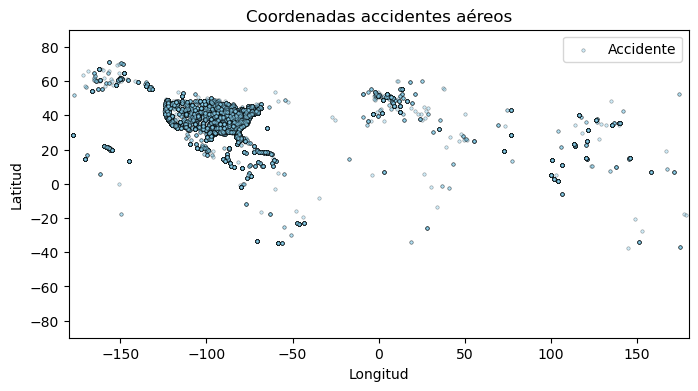

In [110]:
# Scatter plot
from numpy.random import rand
fig, ax = plt.subplots(figsize=(8, 4))

y=df_aircraft['LATITUD_CLEAN']
x=df_aircraft['LONGITUD_CLEAN']

ax.scatter(x, y, c="skyblue" , label="Accidente" , alpha=0.4, s=6, linewidth=0.4, edgecolor='black')
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas accidentes aéreos")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

ax.legend()
plt.show()


In [66]:
df_aircraft.drop(columns=["LATITUDE", "LONGITUDE"])

,INCIDENT_DATE,AIRPORT,AIRCRAFT,DAMAGE_LEVEL,LATITUD_CLEAN,LONGITUD_CLEAN
2,7/1/1996,EPPLEY AIRFIELD,B-757-200,N,41.30252,-95.89417
3,7/1/1996,WASHINGTON DULLES INTL ARPT,A-320,N,38.94453,-77.45581
4,7/1/1996,LA GUARDIA ARPT,A-320,M,40.77724,-73.87261
5,5/6/1991,SAN ANTONIO INTL,B-727-100,N,29.53369,-98.46978
6,11/5/1993,KANSAS CITY INTL,BE-1900,M,39.29761,-94.71391
...,...,...,...,...,...,...
288795,8/28/2023,SOUTHWEST FLORIDA INTL ARPT,A-321,N,26.53617,-81.75517
288798,8/28/2023,SACRAMENTO INTL,B-737-8,N,38.69542,-121.59077
288804,8/28/2023,DENVER INTL AIRPORT,B-737-8,N,39.85841,-104.66700
288807,8/28/2023,DETROIT METRO WAYNE COUNTY ARPT,CRJ900,N,42.21206,-83.34884


–D. Muestra en una figura un conteo de incidentes sobre la columna "AIRCRAFT" por año, en el gráfico debe aparecer una columna por cada "DAMAGE_LEVEL" distinto en el dataframe. La gráfica debe ser de tipo linea con diferentes subplots. Pista, agrupa primero y aplique una gráfica de relación.

In [67]:
df_aircraft["INCIDENT_DATE"] = pd.to_datetime(df_aircraft["INCIDENT_DATE"], errors="coerce") #
# Normaliza la fecha
df_aircraft.groupby("INCIDENT_DATE")["AIRCRAFT"].count()


INCIDENT_DATE
1990-01-02    1
1990-01-08    1
1990-01-11    2
1990-01-19    2
1990-01-20    1
             ..
2023-10-27    1
2023-10-29    1
2023-10-30    1
2023-11-09    1
2023-11-14    2
Name: AIRCRAFT, Length: 12193, dtype: int64

In [68]:
df_aircraft["YEAR"] = df_aircraft["INCIDENT_DATE"].dt.year
df_aircraft["YEAR"]

2         1996
3         1996
4         1996
5         1991
6         1993
          ... 
288795    2023
288798    2023
288804    2023
288807    2023
288808    2023
Name: YEAR, Length: 154012, dtype: int32

In [69]:
estados=[]
for estado in df_aircraft["DAMAGE_LEVEL"]: 
    if estado not in estados:
        estados.append(estado)
len(estados)

4

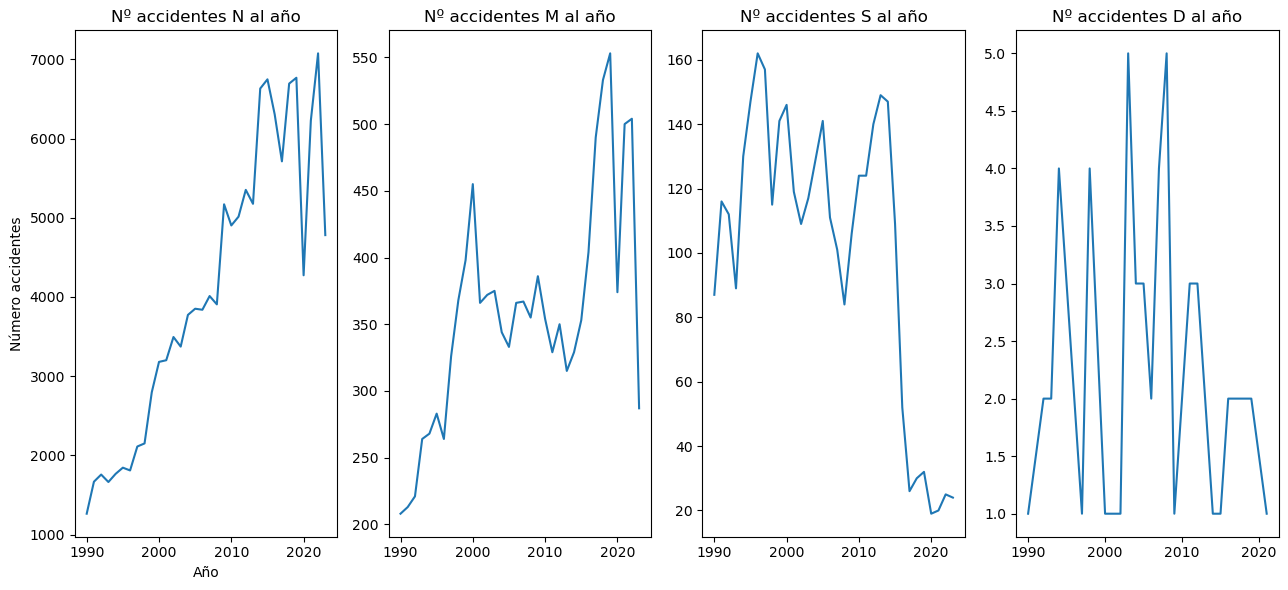

In [70]:


# Paso 1. Crear figura y varios ejes
fig , axs = plt.subplots (1 , len(estados), figsize =(13, 6))

# 2. Dibujar datos en cada eje
for n in range(len(estados)): 
    y = (df_aircraft[df_aircraft["DAMAGE_LEVEL"] == estados[n]].groupby("YEAR")["AIRCRAFT"].count())
    axs[n].plot(y)
    axs[n].set_title(f"Nº accidentes {estados[n]} al año")


# 3. Configurar cada eje
axs[0].set_xlabel ("Año")
axs[0].set_ylabel ("Número accidentes")

# Paso 5: ajustes globales
plt.tight_layout () # Evita solapamientos

# Paso 6: elementos auxiliares
ax.legend ()
ax.grid(True)
# Paso 7: mostrar el gráfico
plt.show ()

2.Carga el fichero 01MIAR_airports.csv en un dataframe de Pandas y:

–A. Muestra el número de filas y columnas

–B. Cambia los valores a minúsculas de columna de nombre de aeropuerto en este dataframe y en el del apartado anterior.

–C. Con el propósito de disponer del país de los aeropuertos, junta ambos dataframes para obtener un nuevo dataframe con todos los registros de incidentes de avión y los países de los aeropuertos. Como clave, utilizar el nombre del aeropuerto modificado en el anterior apartado.

–D. Como resultado se debe disponer un dataframe con 254222 registros.

–E. Muestra el número de registros que no disponen de dato en el atributo "iso_country".

–F. Elimina todos los registros que que tengan nulos alguna de las columnas 'DAMAGE_LEVEL' y 'iso_country'.

–G. Sobre el resultado anterior, crea una tabla contando el número de incidentes por país, en las filas deben aparecer todos los paises posibles y en las columnas debe de estar el tipo de 'DAMAGE_LEVEL'.

In [71]:
# 2)

# Se establece la ruta del dataset
ruta2 = os.path.join("res", "01MIAR_airports.csv")
df_airports = pd.read_csv(ruta2, sep=",")

In [72]:
# A 
display(df_airports)
a=df_airports.shape
print(f" El número de filas es {a[0]} y el número de columnas es {a[1]}")

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,gps_code,iata_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,K00A,NaN,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,00AA,NaN,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,00AK,NaN,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,00AL,NaN,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,00AN,NaN,00AN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77453,46378,ZZ-0001,heliport,Sealand Helipad,51.894444,1.482500,40.0,EU,GB,GB-ENG,Sealand,no,NaN,NaN,NaN,http://www.sealandgov.org/,https://en.wikipedia.org/wiki/Principality_of_...,Roughs Tower Helipad
77454,307326,ZZ-0002,small_airport,Glorioso Islands Airstrip,-11.584278,47.296389,11.0,AF,TF,TF-U-A,Grande Glorieuse,no,NaN,NaN,NaN,NaN,NaN,NaN
77455,346788,ZZ-0003,small_airport,Fainting Goat Airport,32.110587,-97.356312,690.0,NaN,US,US-TX,Blum,no,87TX,NaN,87TX,NaN,NaN,NaN
77456,342102,ZZZW,closed,Scandium City Heliport,69.355287,-138.939310,4.0,NaN,CA,CA-YT,(Old) Scandium City,no,NaN,NaN,NaN,NaN,NaN,"ZZZW, ZZZW, ZYW, YK96"


 El número de filas es 77458 y el número de columnas es 18


In [91]:
# B. Cambia los valores a minúsculas de columna de nombre de aeropuerto en este dataframe y en el del apartado anterior. 
def minus(celda):
    return celda.lower().strip()

In [92]:
df_airports["name"]=df_airports["name"].apply(minus)
df_aircraft['AIRPORT']=df_aircraft['AIRPORT'].apply(minus)

In [93]:
df_airports["name"]

0                total rf heliport
1             aero b ranch airport
2                     lowell field
3                     epps airpark
4             katmai lodge airport
                   ...            
77453              sealand helipad
77454    glorioso islands airstrip
77455        fainting goat airport
77456       scandium city heliport
77457       satsuma iōjima airport
Name: name, Length: 77458, dtype: object

In [94]:
df_aircraft['AIRPORT']

2                         eppley airfield
3             washington dulles intl arpt
4                         la guardia arpt
5                        san antonio intl
6                        kansas city intl
                       ...               
288795        southwest florida intl arpt
288798                    sacramento intl
288804                denver intl airport
288807    detroit metro wayne county arpt
288808            pocatello regional arpt
Name: AIRPORT, Length: 154012, dtype: object

–C. Con el propósito de disponer del país de los aeropuertos, junta ambos dataframes para obtener un nuevo dataframe con todos los registros de incidentes de avión y los países de los aeropuertos. Como clave, utilizar el nombre del aeropuerto modificado en el anterior apartado.

In [132]:
df_merge=pd.merge(df_aircraft , df_airports , left_on ="AIRPORT", right_on ="name", how="outer")

–D. Como resultado se debe disponer un dataframe con 254222 registros.

In [134]:
df_merge.shape

(231895, 27)

–E. Muestra el número de registros que no disponen de dato en el atributo "iso_country".

In [136]:
df_merge["iso_country"].isnull().sum()

np.int64(149688)

–F. Elimina todos los registros que que tengan nulos alguna de las columnas 'DAMAGE_LEVEL' y 'iso_country'.

In [141]:
df_merge = df_merge.dropna(subset=["iso_country", "DAMAGE_LEVEL"])
df_merge

,INCIDENT_DATE,AIRPORT,LATITUDE,LONGITUDE,AIRCRAFT,DAMAGE_LEVEL,LATITUD_CLEAN,LONGITUD_CLEAN,YEAR,id,...,iso_country,iso_region,municipality,scheduled_service,gps_code,iata_code,local_code,home_link,wikipedia_link,keywords
841,1990-05-02,addison airport,32.96856,-96.83645,DASSAULT-10 FALCON,S,32.96856,-96.83645,1990.0,19237.0,...,US,US-TX,Dallas,no,KADS,ADS,ADS,NaN,https://en.wikipedia.org/wiki/Addison_Airport,NaN
842,1990-10-04,addison airport,32.96856,-96.83645,WACO,N,32.96856,-96.83645,1990.0,19237.0,...,US,US-TX,Dallas,no,KADS,ADS,ADS,NaN,https://en.wikipedia.org/wiki/Addison_Airport,NaN
843,1990-06-24,addison airport,32.96856,-96.83645,C-152,N,32.96856,-96.83645,1990.0,19237.0,...,US,US-TX,Dallas,no,KADS,ADS,ADS,NaN,https://en.wikipedia.org/wiki/Addison_Airport,NaN
844,1990-10-11,addison airport,32.96856,-96.83645,C-172,N,32.96856,-96.83645,1990.0,19237.0,...,US,US-TX,Dallas,no,KADS,ADS,ADS,NaN,https://en.wikipedia.org/wiki/Addison_Airport,NaN
845,1991-08-27,addison airport,32.96856,-96.83645,PA-23 APACHE,S,32.96856,-96.83645,1991.0,19237.0,...,US,US-TX,Dallas,no,KADS,ADS,ADS,NaN,https://en.wikipedia.org/wiki/Addison_Airport,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230471,2021-04-13,yap international airport,9.49891,138.08248,B-767-300,N,9.49891,138.08248,2021.0,5503.0,...,FM,FM-YAP,Yap Island,yes,PTYA,YAP,T11,NaN,https://en.wikipedia.org/wiki/Yap_Internationa...,NaN
230472,2022-09-15,yap international airport,9.49891,138.08248,B-757-200,N,9.49891,138.08248,2022.0,5503.0,...,FM,FM-YAP,Yap Island,yes,PTYA,YAP,T11,NaN,https://en.wikipedia.org/wiki/Yap_Internationa...,NaN
230473,2022-10-13,yap international airport,9.49891,138.08248,B-757-200,N,9.49891,138.08248,2022.0,5503.0,...,FM,FM-YAP,Yap Island,yes,PTYA,YAP,T11,NaN,https://en.wikipedia.org/wiki/Yap_Internationa...,NaN
230474,2022-10-13,yap international airport,9.49891,138.08248,B-757-200,N,9.49891,138.08248,2022.0,5503.0,...,FM,FM-YAP,Yap Island,yes,PTYA,YAP,T11,NaN,https://en.wikipedia.org/wiki/Yap_Internationa...,NaN


–G. Sobre el resultado anterior, crea una tabla contando el número de incidentes por país, en las filas deben aparecer todos los paises posibles y en las columnas debe de estar el tipo de 'DAMAGE_LEVEL'.

In [151]:
tabla = pd.pivot_table(df_merge, index="iso_country", columns="DAMAGE_LEVEL", values="AIRCRAFT", aggfunc="count")
tabla.fillna(0)

DAMAGE_LEVEL,D,M,N,S
iso_country,,,,
BR,0.0,0.0,1.0,0.0
BZ,0.0,0.0,1.0,0.0
CA,0.0,6.0,4.0,1.0
DM,0.0,0.0,1.0,0.0
ES,0.0,1.0,7.0,0.0
FM,0.0,0.0,7.0,0.0
GB,0.0,14.0,315.0,3.0
GY,0.0,6.0,4.0,1.0
IE,0.0,0.0,2.0,0.0


In [149]:
grouped = df_merge.groupby(["iso_country", 'DAMAGE_LEVEL']).size().unstack(fill_value=0)
display(grouped)

DAMAGE_LEVEL,D,M,N,S
iso_country,,,,
BR,0,0,1,0
BZ,0,0,1,0
CA,0,6,4,1
DM,0,0,1,0
ES,0,1,7,0
FM,0,0,7,0
GB,0,14,315,3
GY,0,6,4,1
IE,0,0,2,0
